epochs=0, cost=1.67500722, W1=-1.38471770, W2=3.11073303,... b=-0.26199397, accuracy=0.29907773
epochs=500, cost=1.07087636, W1=-1.81597590, W2=2.63992715,... b=0.46867895, accuracy=0.45191041
epochs=1000, cost=0.93983567, W1=-1.87219310, W2=2.07786155,... b=0.45720869, accuracy=0.51515152
epochs=1500, cost=0.84311992, W1=-1.84704781, W2=1.54440928,... b=0.34761336, accuracy=0.56785244
epochs=2000, cost=0.76563287, W1=-1.79523754, W2=1.05813777,... b=0.24898238, accuracy=0.59288538
epochs=2500, cost=0.70438010, W1=-1.73011136, W2=0.62194741,... b=0.17450860, accuracy=0.61791831
epochs=3000, cost=0.65645355, W1=-1.65820622, W2=0.23406832,... b=0.12156676, accuracy=0.62845850
epochs=3500, cost=0.61915600, W1=-1.58424842, W2=-0.10926998,... b=0.08552016, accuracy=0.65349144
epochs=4000, cost=0.59018201, W1=-1.51169288, W2=-0.41267529,... b=0.06214413, accuracy=0.67588933
epochs=4500, cost=0.56765074, W1=-1.44283891, W2=-0.68092597,... b=0.04802814, accuracy=0.69433465
epochs=5000, cost=0.

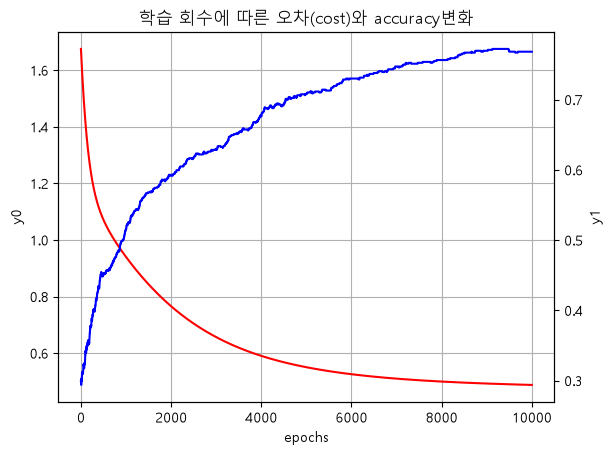

W = [[-1.0124278 ]
 [-2.3014822 ]
 [-0.03395974]
 [-0.67291635]
 [-0.13262156]
 [-1.4830526 ]
 [-0.6316815 ]
 [-0.1697084 ]]
b = 0.07708511
Accuracy = 0.7681159420289855


In [1]:
############################################################################
### ppt 712 당뇨데이터를 활용한 당뇨 예측 (다중로지스틱회귀) tf 2.x ############
############################################################################
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt

# 당뇨병 데이터 읽어오기
xy = np.loadtxt('Data/data-03-diabetes.csv', delimiter=',', dtype=np.float32)
# xy = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/data-03-diabetes.csv', delimiter=',', dtype=np.float32)
x_data = xy[:, 0:-1]     ## 0~7열 까지 총 8개 x값
y_data = xy[:, [-1]]     ## 마지막 열(9열)

W = tf.Variable(tf.random.normal([8, 1]), name='weight')
b = tf.Variable(tf.random.normal([1]), name='bias')

# Hypothesis
def hypothesis(W, b) :
    return tf.sigmoid(tf.matmul(x_data, W) + b)

############################################################################
### ppt 712 당뇨데이터를 활용한 당뇨 예측 (다중로지스틱회귀) tf 2.x ############
############################################################################

def cost(W, b):
    return - tf.reduce_mean(y_data * tf.math.log(hypothesis(W, b)) + 
                           (1 - y_data) * tf.math.log(1 - hypothesis(W, b)))

def graph():
    #import matplotlib as mpl
    plt.rc('font', family='Malgun Gothic') # 한글 설정
    plt.rc('axes', unicode_minus=False)    # 음수부호 설정
    fig, ax0 = plt.subplots()
    ax1 = ax0.twinx()   # x축을 공유하는 두개의 y축
    ax0.set_title("학습 회수에 따른 오차(cost)와 accuracy변화")
    ax0.plot(cost_arr, 'r-', label="y0")
    ax0.set_ylabel("y0")
    ax0.grid(True)
    ax1.plot(accuracy_arr, 'b', label="y1")
    ax1.set_ylabel("y1")
    ax1.grid(False)
    ax0.set_xlabel("epochs")
    plt.show()

opt = tf.keras.optimizers.SGD(learning_rate=0.01)

epoch_arr = []
cost_arr = []
accuracy_arr = []

############################################################################
### ppt 712 당뇨데이터를 활용한 당뇨 예측 (다중로지스틱회귀) tf 2.x ############
############################################################################

for step in range(10001): # steps
    with tf.GradientTape() as tape:
        cost_value = cost(W, b)
    gradients = tape.gradient(cost_value, [W, b])
    opt.apply_gradients(zip(gradients, [W, b]))
    
    predicted = tf.cast(hypothesis(W, b) > 0.5, dtype=tf.float64) ## 학습중인 W, b로 예측한 값(텐서)
    epoch_arr.append(step)                    # 학습수 누적 array
    cost_arr.append(cost_value.numpy())       # cost 누적 array
    accuracy = np.mean(y_data == predicted)   # y_data와 계산된 predicted 요소가 일치하는 확률
    accuracy_arr.append(accuracy)             # accuracy 누적 array
    
    if step % 500 == 0: 
        print("epochs=%d, cost=%.8f, W1=%.8f, W2=%.8f,... b=%.8f, accuracy=%.8f" % 
              (step, cost_value, W.numpy()[0,0], W.numpy()[1, 0], b.numpy()[0], accuracy)) 


graph()   # cost와 accuracy 그래프 그리기

print("========================================================")
print("W =", W.numpy())
print("b =", b.numpy()[0])
# print("y_data =", y_data)
# print("sigmoid =", hypothesis(W, b).numpy())

predicted = tf.cast(hypothesis(W, b) > 0.5, dtype=tf.float64)
accuracy = np.mean(y_data == predicted) 
# accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted, y_data), dtype=tf.float64)).numpy()

# print("predicted =", predicted.numpy())
print("Accuracy =", accuracy)

In [3]:
new_data = np.array([
    [-0.882353, -0.105528, 0.0819672, -0.535354,
     -0.777778, -0.162444, -0.923997, 0],          # 1
    [-0.764706, -0.286432, 0.147541, -0.454545,
     0, -0.165425, -0.566183, -0.966667],          # 1
    [-0.882353, -0.0251256, 0.0819672, -0.69697,
     -0.669031, -0.308495, -0.650726, -0.966667],  # 1
    [0.176471, 0.256281, 0.147541, -0.474747,
     -0.728132, -0.0730253, -0.891546, -0.333333], # 0
    [-0.647059, 0.708543, 0.0491803, -0.252525,
     -0.468085, 0.028316, -0.762596, -0.7],        # 0
    [0.0588235, 0.718593, 0.803279, -0.515152,
     -0.432624, 0.353204, -0.450897, 0.1]          # 0
], dtype=np.float32)

print("W = ", W.numpy())
print("b =", b.numpy()[0])

trained_W = W
trained_b = b
def predict(X, W, b):
    logits = tf.matmul(X, W) + b
    prob = tf.sigmoid(logits)
    label = tf.cast(prob > 0.5, tf.int32)
    return prob, label

X_tensor = tf.constant(new_data, dtype=tf.float32)
predicted_prob, predicted_label = predict(X_tensor, trained_W, trained_b)

for i in range(len(new_data)):
    print(f"입력 {i+1}: 예측 = {predicted_label.numpy()[i][0]}, 확률 = {predicted_prob.numpy()[i][0]:.4f}")

W =  [[-1.0124278 ]
 [-2.3014822 ]
 [-0.03395974]
 [-0.67291635]
 [-0.13262156]
 [-1.4830526 ]
 [-0.6316815 ]
 [-0.1697084 ]]
b = 0.07708511
입력 1: 예측 = 1, 확률 = 0.9240
입력 2: 예측 = 1, 확률 = 0.9295
입력 3: 예측 = 1, 확률 = 0.9319
입력 4: 예측 = 1, 확률 = 0.6101
입력 5: 예측 = 0, 확률 = 0.4726
입력 6: 예측 = 0, 확률 = 0.1801


퍼셉트론, 딥러닝

In [11]:
#퍼셉트론 And 연산

import numpy as np
import tensorflow as tf


X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
Y = np.array([[0], [0], [0], [1]])

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

W = tf.Variable(tf.random.normal([2, 1]), dtype=tf.float32)
b = tf.Variable(tf.random.normal([1]), dtype=tf.float32)

def hypothesis(X) :
    z = tf.matmul(X, W) + b
    return tf.sigmoid(z)

def cost():
    pred = hypothesis(X)
    cost = tf.reduce_mean(tf.keras.losses.binary_crossentropy(Y, pred))
    return cost

opt = tf.keras.optimizers.SGD(learning_rate=0.1)

for i in range(2001):
    with tf.GradientTape() as tape:
        current_cost = cost()
    grads = tape.gradient(current_cost, [W,b])
    opt.apply_gradients(zip(grads, [W, b]))

    if i % 200 == 0:
        print(f"Step: {i}, Loss: {current_cost.numpy():.4f}")


print("\n--------예측결과------------")

pred = hypothesis(X).numpy()
pred_binary = (pred>0.5).astype(int)

for i in range(len(X)):
    print(f"입력: {X[i]}, 예측(확률): {pred[i][0]:.2f}, 예측(이진): {pred_binary[i][0]}")

accuracy = np.mean(pred_binary == Y)
print(f"\n정확도(Accuracy): {accuracy:.2f}")

Step: 0, Loss: 1.4388
Step: 200, Loss: 0.3475
Step: 400, Loss: 0.2512
Step: 600, Loss: 0.1988
Step: 800, Loss: 0.1649
Step: 1000, Loss: 0.1408
Step: 1200, Loss: 0.1228
Step: 1400, Loss: 0.1088
Step: 1600, Loss: 0.0976
Step: 1800, Loss: 0.0884
Step: 2000, Loss: 0.0807

--------예측결과------------
입력: [0. 0.], 예측(확률): 0.00, 예측(이진): 0
입력: [0. 1.], 예측(확률): 0.09, 예측(이진): 0
입력: [1. 0.], 예측(확률): 0.09, 예측(이진): 0
입력: [1. 1.], 예측(확률): 0.87, 예측(이진): 1

정확도(Accuracy): 1.00


In [12]:
#퍼셉트론 Or 연산

import numpy as np
import tensorflow as tf


X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
Y = np.array([[0], [1], [1], [1]])

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

W = tf.Variable(tf.random.normal([2, 1]), dtype=tf.float32)
b = tf.Variable(tf.random.normal([1]), dtype=tf.float32)

def hypothesis(X) :
    z = tf.matmul(X, W) + b
    return tf.sigmoid(z)

def cost():
    pred = hypothesis(X)
    cost = tf.reduce_mean(tf.keras.losses.binary_crossentropy(Y, pred))
    return cost

opt = tf.keras.optimizers.SGD(learning_rate=0.1)

for i in range(2001):
    with tf.GradientTape() as tape:
        current_cost = cost()
    grads = tape.gradient(current_cost, [W,b])
    opt.apply_gradients(zip(grads, [W, b]))

    if i % 200 == 0:
        print(f"Step: {i}, Loss: {current_cost.numpy():.4f}")


print("\n--------예측결과------------")

pred = hypothesis(X).numpy()
pred_binary = (pred>0.5).astype(int)

for i in range(len(X)):
    print(f"입력: {X[i]}, 예측(확률): {pred[i][0]:.2f}, 예측(이진): {pred_binary[i][0]}")

accuracy = np.mean(pred_binary == Y)
print(f"\n정확도(Accuracy): {accuracy:.2f}")

Step: 0, Loss: 0.4219
Step: 200, Loss: 0.2433
Step: 400, Loss: 0.1696
Step: 600, Loss: 0.1291
Step: 800, Loss: 0.1036
Step: 1000, Loss: 0.0862
Step: 1200, Loss: 0.0737
Step: 1400, Loss: 0.0642
Step: 1600, Loss: 0.0568
Step: 1800, Loss: 0.0509
Step: 2000, Loss: 0.0460

--------예측결과------------
입력: [0. 0.], 예측(확률): 0.10, 예측(이진): 0
입력: [0. 1.], 예측(확률): 0.96, 예측(이진): 1
입력: [1. 0.], 예측(확률): 0.96, 예측(이진): 1
입력: [1. 1.], 예측(확률): 1.00, 예측(이진): 1

정확도(Accuracy): 1.00


In [17]:
#퍼셉트론 Xor 연산
#다층 퍼셉트론 실습

import numpy as np
import tensorflow as tf


X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=np.float32)
Y = np.array([[0], [1], [1], [0]])

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

#은닉층 가중치와 편향
W1 = tf.Variable(tf.random.normal([2, 2]), dtype=tf.float32)
b1 = tf.Variable(tf.random.normal([2]), dtype=tf.float32)
#출력층 가중치와 편향
W2 = tf.Variable(tf.random.normal([2, 1]), dtype=tf.float32)
b2 = tf.Variable(tf.random.normal([1]), dtype=tf.float32)

def hypothesis(X) :
    return 1 / (1+tf.exp(-X))

#다층 퍼셉트론 정의 (은닉층 -> 출력층)
def perceptron(X):
    hidden = hypothesis(tf.matmul(X, W1) + b1)
    return hypothesis(tf.matmul(hidden, W2)+b2)

def cost(y_true, y_pred):
    return tf.reduce_mean(-(y_true * tf.math.log(y_pred) 
                            + (1-y_true) * tf.math.log(1-y_pred)))

opt = tf.keras.optimizers.SGD(learning_rate=0.5)

def binary_output(X):
    return int(X.numpy()[0][0] > 0.5)

def accuracy(y_true, y_pred):
    correct_prediction = tf.equal(tf.cast(y_pred > 0.5, tf.float32), y_true)
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

for i in range(2001):
    with tf.GradientTape() as tape:
        pred = perceptron(X)
        loss = cost(Y, pred)
    grads = tape.gradient(loss, [W1, W2 ,b1, b2])
    opt.apply_gradients(zip(grads, [W1, W2, b1, b2]))

    if i % 200 == 0:
        W1_val = np.squeeze(W1.numpy())
        b1_val = np.squeeze(b1.numpy())
        W2_val = np.squeeze(W2.numpy())
        b2_val = np.squeeze(b2.numpy())
        print(f"Step: {i}, Loss: {loss.numpy():.9f}")
        print(f"W1 = {W1_val}, b1 = {b1_val}")
        print(f"W2 = {W2_val}, b2 = {b2_val}")

print("\n--------예측결과------------")

for input_data in X:
    prediction = perceptron(np.array([input_data], dtype=np.float32))
    print(f"입력: {input_data.tolist()}, 예측(확률): {prediction.numpy()[0][0]:.4f}, 예측(이진): {binary_output(prediction)}")


predictions = perceptron(X)
acc = accuracy(Y, predictions)
print(f"정확도: {acc.numpy():.4f}")

Step: 0, Loss: 0.690912127
W1 = [[ 1.5141448   0.42299533]
 [-0.42845955 -1.0354583 ]], b1 = [1.0751604  0.19548124]
W2 = [-1.8236368  -0.12010581], b2 = 1.6754565238952637
Step: 200, Loss: 0.567427397
W1 = [[ 3.010264   0.7170952]
 [-2.6449692 -1.3513446]], b1 = [2.000483   0.02259614]
W2 = [-2.9296885  1.0850923], b2 = 1.819110631942749
Step: 400, Loss: 0.202259094
W1 = [[ 4.5473776  3.0086296]
 [-4.4394917 -3.4567873]], b1 = [ 2.6506002 -1.5181272]
W2 = [-5.0024743  4.6570854], b2 = 2.426659345626831
Step: 600, Loss: 0.076809242
W1 = [[ 5.2758284  4.2151694]
 [-5.2187614 -4.573172 ]], b1 = [ 2.8393784 -2.2255192]
W2 = [-6.5317726  6.824899 ], b2 = 2.9984145164489746
Step: 800, Loss: 0.044885702
W1 = [[ 5.663313   4.734188 ]
 [-5.5962    -5.0712504]], b1 = [ 2.9537082 -2.516002 ]
W2 = [-7.4539313  7.9132676], b2 = 3.410548686981201
Step: 1000, Loss: 0.031265464
W1 = [[ 5.915042   5.0447173]
 [-5.8338637 -5.371417 ]], b1 = [ 3.036053  -2.6852381]
W2 = [-8.095828  8.61977 ], b2 = 3.713